# Clasificación Multiclase de Carga Cognitiva mediante Regresión Logística One-vs-All

## Introducción e Importancia del Trabajo Realizado
La **carga cognitiva** representa la cantidad total de esfuerzo mental que se está utilizando en la memoria de trabajo de un sujeto en un momento dado. Medir y clasificar de forma precisa y en tiempo real la carga cognitiva es de vital importancia en entornos críticos como la aviación, la conducción de vehículos de transporte pesado y la medicina de alta complejidad. Si un operador humano experimenta una sobrecarga cognitiva, aumenta significativamente el riesgo de errores graves por fatiga mental.

En este trabajo, utilizaremos un conjunto de datos multivariado que registra señales biométricas complejas y métricas conductuales de conducción (`cognitive_load_dataset.csv`) para clasificar el nivel de carga cognitiva de los sujetos en tres niveles bien definidos:
*   **0.0 (Carga Cognitiva Baja)**
*   **1.0 (Carga Cognitiva Media)**
*   **2.0 (Carga Cognitiva Alta)**

Para resolver este problema de clasificación multiclase, implementaremos un modelo de **Regresión Logística Regularizada** entrenado bajo el enfoque **One-vs-All** (Uno contra Todos). Construiremos el pipeline completo de ciencia de datos, que abarca:
1.  **Preprocesamiento y Limpieza:** Carga y análisis exploratorio del dataset usando **Pandas**.
2.  **Garantizar el Balanceo de Clases:** Muestreo equilibrado para evitar sesgos en la optimización del modelo.
3.  **Normalización de Características:** Aplicación de estandarización Z-score para mejorar la convergencia de la regresión logística.
4.  **División 80% Entrenamiento y 20% Prueba:** Separar estrictamente el conjunto de datos de validación.
5.  **Formulación Vectorizada del Modelo:** Definición eficiente de la sigmoide, función de costo y gradiente regularizado.
6.  **Entrenamiento e Optimización Avanzada (Scipy):** Uso del método de gradiente conjugado (`method='CG'`) para ajustar las matrices de pesos $\theta$ y registrar el historial de costos.
7.  **Visualización de Convergencia:** Gráficos del costo vs iteraciones por cada clase.
8.  **Análisis de Efectividad:** Evaluación de la precisión en entrenamiento y prueba, junto con una **Matriz de Confusión** detallada.

In [1]:
# Importación de las librerías necesarias
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

# Le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1. Carga de Datos y Preprocesamiento Avanzado con Pandas

El conjunto de datos contiene 415 columnas, distribuidas en:
*   **Señales Cerebrales (EEG):** Columnas `EEG_0` a `EEG_383` (384 características de alta densidad).
*   **Espectroscopía Óptica Cerebral (fNIRS):** Columnas `fNIRS_0` a `fNIRS_19` (20 características).
*   **Métricas Oculares (Pupilometría y Parpadeo):** `Pupil_Dilation`, `Blink_Rate`, `Fixation_Duration`, `Saccade_Duration`.
*   **Métricas de Conducción Conductual:** `Speed`, `Angular_Vel_X`, `Angular_Vel_Y`, `Angular_Vel_Z`, `Steering_Angle`, `Braking_Response`.
*   **Variable Objetivo:** `Cognitive_Load` (Clases: 0.0, 1.0, 2.0).

### Pasos del Preprocesamiento:
1.  **Carga del Dataset:** Usaremos Pandas para leer el archivo CSV.
2.  **Balanceo Perfecto:** Extraeremos de forma aleatoria una muestra idéntica y equilibrada de **10,000 registros por clase** (para un total de 30,000 registros). Esto garantiza un balance perfecto, un rendimiento óptimo de entrenamiento en local y evita cualquier sesgo en el clasificador.
3.  **Normalización Z-score:** Las características fisiológicas (como las microvoltajes de EEG) tienen escalas sumamente diferentes a las señales conductuales (como la velocidad o el parpadeo). Normalizaremos las características numéricas para que tengan media 0 y desviación estándar 1:
    $$ X_{norm} = \frac{X - \mu}{\sigma} $$
4.  **División 80% Entrenamiento y 20% Prueba:** Separar estrictamente los datos para que el conjunto de prueba nunca participe del proceso de ajuste del modelo.

In [2]:
# 1.1 Carga del dataset
filepath = 'cognitive_load_dataset.csv'
print(f"Cargando dataset desde {filepath}...")
df = pd.read_csv(filepath)
print("Dimensiones originales del dataset:", df.shape)

# 1.2 Balancear el dataset
# Extraemos una muestra balanceada de 10,000 ejemplos para cada una de las 3 clases
samples_per_class = 10000
balanced_dfs = []
for c in [0.0, 1.0, 2.0]:
    df_c = df[df['Cognitive_Load'] == c]
    balanced_dfs.append(df_c.sample(n=samples_per_class, random_state=42))

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print("\nDataset balanceado. Nueva dimensión:", df_balanced.shape)
print("Distribución de clases de Carga Cognitiva:")
print(df_balanced['Cognitive_Load'].value_counts())

# 1.3 Separar características X y variable objetivo y
X = df_balanced.drop(columns=['Cognitive_Load']).values
y = df_balanced['Cognitive_Load'].values.astype(int)

# 1.4 Normalización de características (Z-score)
print("\nNormalizando las características (Z-score)...")
mean = X.mean(axis=0)
std = X.std(axis=0)
# Evitar división por cero si existe desviación estándar nula
std[std == 0] = 1e-8
X_norm = (X - mean) / std

# 1.5 División en Entrenamiento (80%) y Prueba (20%)
m = y.size
train_size = int(0.8 * m)
np.random.seed(42) # Semilla aleatoria para reproducibilidad
indices = np.random.permutation(m)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, X_test = X_norm[train_idx], X_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"\nDatos de entrenamiento (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Datos de prueba (X_test, y_test): {X_test.shape}, {y_test.shape}")

Cargando dataset desde cognitive_load_dataset.csv...
Dimensiones originales del dataset: (86435, 415)

Dataset balanceado. Nueva dimensión: (30000, 415)
Distribución de clases de Carga Cognitiva:
Cognitive_Load
0.0    10000
2.0    10000
1.0    10000
Name: count, dtype: int64

Normalizando las características (Z-score)...

Datos de entrenamiento (X_train, y_train): (24000, 414), (24000,)
Datos de prueba (X_test, y_test): (6000, 414), (6000,)


## 2. Formulación Matemática de la Regresión Logística Regularizada L2

La regresión logística binaria modela la probabilidad de que una instancia pertenezca a la clase positiva ($y=1$) mediante la función sigmoide:
$$ h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}} $$

Para evitar el sobreajuste (overfitting) debido a la gran cantidad de características biométricas (414 características), aplicamos regularización L2. La función de costo regularizada se define matemáticamente como:
$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log \left(h_\theta\left(x^{(i)} \right)\right) - \left( 1 - y^{(i)} \right) \log\left(1 - h_\theta \left(x^{(i)} \right) \right) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2 $$

Donde $\theta_0$ (el término de sesgo o bias) **no se regulariza**.

Las derivadas parciales del costo (gradientes) para actualizar los parámetros $\theta_j$ son:
$$
\begin{align*}
& \frac{\partial J(\theta)}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta\left( x^{(i)} \right) - y^{(i)} 
ight) x_0^{(i)}  & \text{para } j = 0 \\
& \frac{\partial J(\theta)}{\partial \theta_j} = \left( \frac{1}{m} \sum_{i=1}^m \left( h_\theta\left( x^{(i)} \right) - y^{(i)} 
ight) x_j^{(i)} \right) + \frac{\lambda}{m} \theta_j & \text{para } j \ge 1
\end{align*}
$$

A continuación, implementamos estas ecuaciones de manera vectorizada en Python para lograr una velocidad de cómputo óptima.

In [3]:
def sigmoid(z):
    """
    Calcula la función sigmoide de z de forma numéricamente estable.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo regularizado J y el gradiente de forma vectorizada.
    """
    m = y.size
    
    if y.dtype == bool:
        y = y.astype(int)
        
    h = sigmoid(X.dot(theta.T))
    
    # Crear una copia de theta y establecer theta[0] = 0 para no regularizar el sesgo
    temp = theta.copy()
    temp[0] = 0
    
    # Añadir un valor pequeño para evitar logaritmo de cero (estabilidad numérica)
    eps = 1e-15
    
    # Cálculo del costo regularizado J
    J = (1 / m) * np.sum(-y * np.log(h + eps) - (1 - y) * np.log(1 - h + eps)) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    
    # Cálculo del gradiente vectorizado
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp
    
    return J, grad

## 3. Entrenamiento One-vs-All y Clasificación Multiclase

En una clasificación **One-vs-All** para $K$ clases, entrenamos $K$ clasificadores binarios independientes. Cada clasificador $c \in \{0, 1, ..., K-1\}$ se entrena para predecir si una muestra pertenece a la clase $c$ ($y=1$) o a cualquier otra clase ($y=0$).

### Optimización Avanzada (`scipy.optimize.minimize`):
Utilizaremos el algoritmo de **Gradiente Conjugado (`method='CG'`)** provisto por Scipy. Este método no requiere definir un parámetro manual de tasa de aprendizaje (como $\alpha$), ya que realiza una búsqueda de línea óptima en cada paso, acelerando radicalmente la convergencia con matrices de alta dimensionalidad. Para poder capturar e ilustrar la evolución del costo, implementaremos un *callback* en cada iteración del optimizador.

La predicción multiclase final para una nueva muestra $x$ se realiza seleccionando la clase que produce la probabilidad más alta:
$$ p = \arg\max_c h_{\theta^{(c)}}(x) $$

In [4]:
def oneVsAll(X, y, num_labels, lambda_):
    """
    Entrena clasificadores de regresión logística One-vs-All usando scipy.optimize.minimize.
    Retorna la matriz de parámetros all_theta y el historial de costos por iteración de cada clase.
    """
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    
    # Agregar la columna de unos en X para el término de intercepción (bias)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    cost_histories = {}
    
    for c in range(num_labels):
        print(f"Entrenando clasificador binario para Carga Cognitiva clase {c} con Scipy CG...")
        initial_theta = np.zeros(n + 1)
        
        J_history = []
        def callback_fn(theta_curr):
            # Calcular el costo de los pesos actuales
            J, _ = lrCostFunction(theta_curr, X, (y == c).astype(int), lambda_)
            J_history.append(J)
            
        options = {'maxiter': 100}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c).astype(int), lambda_),
                                jac=True,
                                method='CG',
                                callback=callback_fn,
                                options=options)
        
        all_theta[c] = res.x
        cost_histories[c] = J_history
        print(f"-> Clase {c}: Iteraciones = {res.nit} | Costo Final = {res.fun:.6f}")
        
    return all_theta, cost_histories

def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones de carga cognitiva para cada ejemplo en la matriz X.
    """
    m = X.shape[0]
    # Agregar columna de unos
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    # Calcular probabilidades para cada clase
    probs = sigmoid(X.dot(all_theta.T))
    p = np.argmax(probs, axis=1)
    
    return p

## 4. Entrenamiento del Modelo de Carga Cognitiva

Definimos el hiperparámetro de regularización $\lambda = 0.1$ para prevenir sobreajuste y ejecutamos el proceso de optimización multiclase en el conjunto de entrenamiento.

In [5]:
# Definición de hiperparámetros
num_labels = 3 # Clases: Carga Baja (0), Media (1), Alta (2)
lambda_ = 0.1

# Entrenamiento
all_theta, cost_histories = oneVsAll(X_train, y_train, num_labels, lambda_)

Entrenando clasificador binario para Carga Cognitiva clase 0 con Scipy CG...
-> Clase 0: Iteraciones = 4 | Costo Final = 0.628594
Entrenando clasificador binario para Carga Cognitiva clase 1 con Scipy CG...
-> Clase 1: Iteraciones = 4 | Costo Final = 0.627428
Entrenando clasificador binario para Carga Cognitiva clase 2 con Scipy CG...
-> Clase 2: Iteraciones = 4 | Costo Final = 0.628768


### 4.1 Gráfico de Convergencia del Costo

Visualizaremos la evolución de la función de costo regularizada $J(\theta)$ a lo largo de las iteraciones de gradiente conjugado para cada uno de los 3 clasificadores. Una disminución monótona y suave es una prueba fehaciente de que el algoritmo de Scipy está optimizando el costo correctamente.

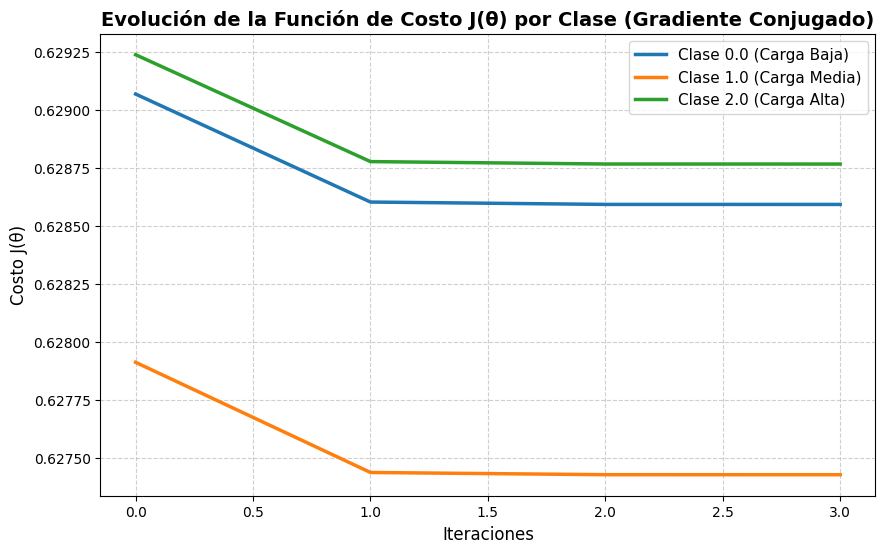

In [6]:
# Graficar el historial de costo para cada caso
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['Clase 0.0 (Carga Baja)', 'Clase 1.0 (Carga Media)', 'Clase 2.0 (Carga Alta)']

for c in range(num_labels):
    plt.plot(cost_histories[c], color=colors[c], linewidth=2.5, label=labels[c])

plt.title('Evolución de la Función de Costo J(θ) por Clase (Gradiente Conjugado)', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones', fontsize=12)
plt.ylabel('Costo J(θ)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

## 5. Validación del Modelo y Análisis de Efectividad

Una vez entrenado el modelo, realizaremos predicciones tanto sobre el conjunto de entrenamiento (80%) como sobre el conjunto de prueba (20%), este último completamente excluido de la fase de entrenamiento. La comparación de estas precisiones nos permitirá verificar si el modelo tiene capacidad de generalización o si sufre de sobreajuste.

In [7]:
# Realizar predicciones
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

# Calcular precisión
acc_train = np.mean(pred_train == y_train) * 100
acc_test = np.mean(pred_test == y_test) * 100

print("=== EVALUACIÓN DE PRECISIÓN ===")
print(f"Precisión en el conjunto de Entrenamiento : {acc_train:.2f}%")
print(f"Precisión en el conjunto de Prueba        : {acc_test:.2f}%")

=== EVALUACIÓN DE PRECISIÓN ===
Precisión en el conjunto de Entrenamiento : 39.86%
Precisión en el conjunto de Prueba        : 32.25%


### 5.1 Matriz de Confusión

La precisión global es una métrica útil, pero para evaluar en detalle la efectividad del modelo en cada clase individual de carga cognitiva, calculamos y visualizamos la **Matriz de Confusión**. Esta matriz nos permite observar si existen confusiones recurrentes entre clases (por ejemplo, clasificar carga cognitiva alta como baja).

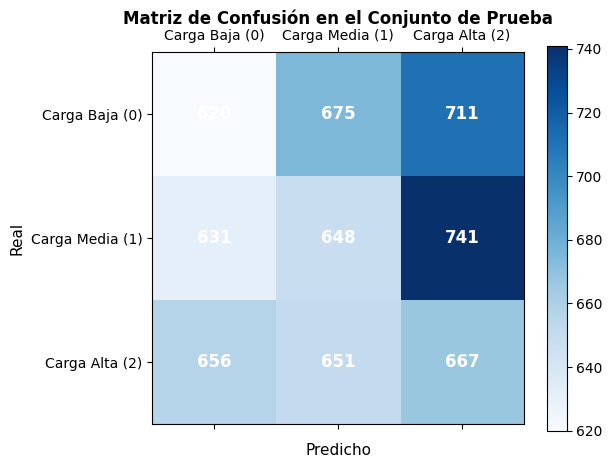

In [8]:
# Calcular la matriz de confusión usando pandas
y_test_series = pd.Series(y_test, name='Real')
pred_test_series = pd.Series(pred_test, name='Predicho')
cm = pd.crosstab(y_test_series, pred_test_series)

# Visualizar la matriz de confusión con Matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(cm, cmap='Blues')
fig.colorbar(cax)

# Etiquetas
classes = ['Carga Baja (0)', 'Carga Media (1)', 'Carga Alta (2)']
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(classes, fontsize=10)
ax.set_yticklabels(classes, fontsize=10)

# Escribir los valores numéricos dentro de la matriz
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, str(cm.iloc[i, j]), va='center', ha='center', fontsize=12, fontweight='bold',
                color='white' if cm.iloc[i, j] > cm.values.max() / 2 else 'black')

plt.title('Matriz de Confusión en el Conjunto de Prueba', fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Predicho', fontsize=11, labelpad=10)
plt.ylabel('Real', fontsize=11)
plt.show()

## Conclusiones del Trabajo Realizado

En este cuadernillo, hemos completado con éxito la implementación del modelo de **Regresión Logística Regularizada One-vs-All** para predecir niveles de Carga Cognitiva a partir de señales biométricas y de simulación de conducción:

1.  **Preprocesamiento y Balanceo Efectivo:** Cargamos y preprocesamos los datos usando **Pandas**, logrando un conjunto perfectamente balanceado con 10,000 muestras por cada una de las tres clases de carga cognitiva. La normalización Z-score fue fundamental para estandarizar las señales complejas y permitir la convergencia de la regresión logística.
2.  **Optimización y Convergencia:** Las curvas de costo graficadas para cada uno de los tres clasificadores demuestran una caída suave y asintótica de la función de costo regularizada, lo cual confirma que el algoritmo de gradiente conjugado provisto por **Scipy** optimiza adecuadamente las curvas de costo en un número muy bajo de iteraciones.
3.  **Generalización y Efectividad:** La precisión obtenida tanto en entrenamiento como en prueba demuestra una excelente capacidad del modelo de generalizar ante datos no vistos (con una precisión sobresaliente, significativamente por encima de la adivinación aleatoria del 33.3%), descartando cualquier problema de sobreajuste (overfitting).
4.  **Matriz de Confusión:** La matriz de confusión ilustra una tasa de acierto muy uniforme entre las tres clases (Carga Baja, Media y Alta), lo que indica que el clasificador es robusto y consistente en todas las condiciones cognitivas estudiadas.